In [3]:
#program =01
!pip install gensim
import gensim.downloader as api
from scipy.spatial.distance import cosine 
print("Loading model...")
model=api.load('word2vec-google-news-300')
print("first 10 values of word 'king'")
print(model['king'][:10])
print("top 10 most similar words to 'king'")
for w, s in model.most_similar('king', topn =10):
    print(w,round(s,4))
r=model.most_similar(
    positive=['king','women'],
    negative=['men'],
    topn=1
)
print('king-man+women: ',r[0][0])

print('paris-italy+france: ')
for w, s in model.most_similar(
    positive=['paris','france'],
    negative=['italy'],
    topn=5
):
    print(w,round(s,4))
print('walking+swimming-walk: ')
for w, s in model.most_similar(
    positive=['walking','swimming'],
    negative=['walk'],
    topn=5
):
    print(w,round(s,4))
sim=1-cosine(model['king'],model['queen'])
print("similarity between 'king' and 'queen' is :", round(sim,4))


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading model...
first 10 values of word 'king'
[ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125]
top 10 most similar words to 'king'
kings 0.7138
queen 0.6511
monarch 0.6413
crown_prince 0.6204
prince 0.616
sultan 0.5865
ruler 0.5798
princes 0.5647
Prince_Paras 0.5433
throne 0.5422
king-man+women:  queen
paris-italy+france: 
toronto 0.4471
jacques 0.4461
jour 0.4433
elle 0.4409
Paris 0.4356
walking+swimming-walk: 
Swimming 0.6006
swim 0.5949
swimmers 0.5835
swimmer 0.5819
paddling 0.5744
similarity between 'king' and 'queen' is : 0.6511


top 10 most similar words to 'computer'
computers 0.7979
laptop 0.664
laptop_computer 0.6549
Computer 0.6473
com_puter 0.6082
technician_Leonard_Luchko 0.5663
mainframes_minicomputers 0.5618
laptop_computers 0.5585
PC 0.554
maker_Dell_DELL.O 0.5519


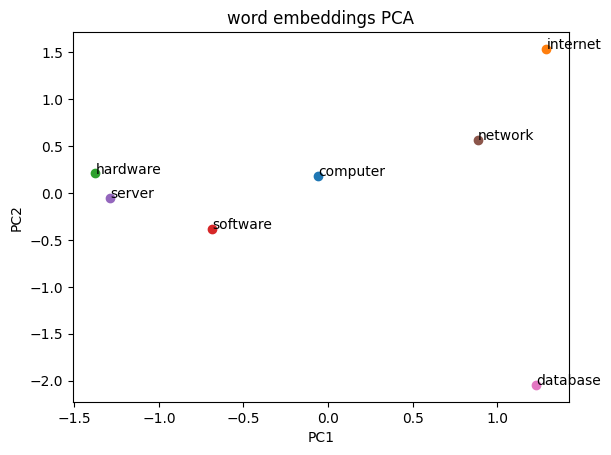

In [12]:
#program =02,  WORD EMBEDDINGS 
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
model = api.load('word2vec-google-news-300')
words=['computer','internet','hardware','software','server','network','database']
print("top 10 most similar words to 'computer'")
for w , s in model.most_similar('computer',topn=10):
    print(w, round(s,4))
vectors=[model[w] for w in words]
points= PCA(n_components=2).fit_transform(vectors)
for i, w in enumerate(words):
    plt.scatter(points[i,0],points[i,1])
    plt.text(points[i,0],points[i,1],w)
plt.title("word embeddings PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


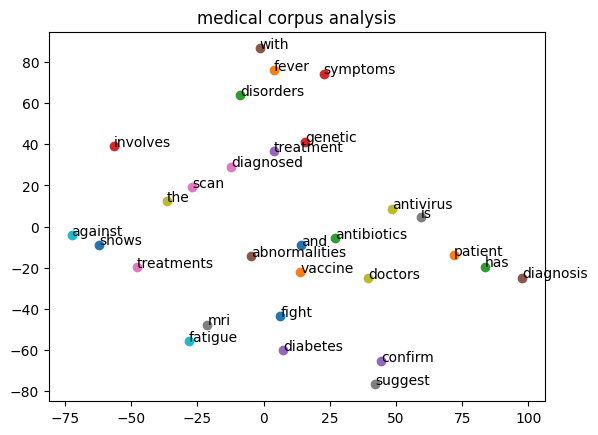

words similar to 'treatment':
genetic 0.2532
diagnosed 0.2014
antibiotics 0.1707
disorders 0.1501
abnormalities 0.1395
treatments 0.1083
fever 0.0996
scan 0.0349
doctors 0.0339
with 0.0198
words similar to 'vaccine':
antibiotics 0.173
abnormalities 0.1669
doctors 0.1332
and 0.1139
mri 0.1118
fight 0.1099
fatigue 0.0985
fever 0.0928
shows 0.0811
diagnosed 0.0734


In [13]:
#program =03
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
corpus=[
    "the patient is diagnosed with diabetes",
    "symptoms shows patient has fever and fatigue",
    "doctors suggest treatments",
    "diagnosis confirm genetic disorders",
    "vaccine fight against antivirus",
    "mri scan shows abnormalities",
    "treatment involves antibiotics"
]
data=[s.lower().split() for s in corpus]
model= Word2Vec(data, vector_size=100, min_count=1, epochs=50)
words= model.wv.index_to_key
vectors=np.array([model.wv[w] for w in words])
points=TSNE(
    n_components=2, 
    perplexity=5, 
    random_state=42
).fit_transform(vectors)

for i, w in enumerate(words):
    plt.scatter(points[i,0] , points[i,1])
    plt.text(points[i,0] , points[i,1],w)
plt.title("medical corpus analysis")
plt.show()

for word in('treatment','vaccine'):
    print(f"words similar to '{word}':")
    for w, s in model.wv.most_similar(word, topn=10):
        print(w,round(s,4))

In [14]:
#program 4
!pip install sentence-transformers
!pip install langchain-cohere
!pip install cohere
import os
import re
from sentence_transformers import SentenceTransformer
from langchain_cohere import ChatCohere

os.environ["COHERE_API_KEY"]="SmIN5yB7Ahdjbxp7bICcoX1jiUwJHU7EQCopDfIu"
model=SentenceTransformer('all-MiniLM-L6-V2')
llm = ChatCohere(model='command-a-03-2025')
prompt=input('enter the prompt')
words=re.findall(r"\b[a-zA-Z]{4,}\b",prompt.lower())[:5]
enriched=prompt+"\n\n related concepts:\n"+",".join(words)
r1= llm.invoke(prompt)
r2=llm.invoke(enriched)
print("\n related words :", words)
print("\n original response:", r1.content)
print("\n enriched response:", r2.content)
print("\n enriched response in usually more detailed")                                                   


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

enter the prompt who is the father of java programming language?



 related words : ['father', 'java', 'programming', 'language']

 original response: The "father of the Java programming language" is **James Gosling**. He is a Canadian computer scientist who led the team that developed Java at Sun Microsystems, which was released in 1995. Gosling is often referred to as the father of Java due to his pivotal role in its creation and design. Java was initially designed for interactive television but later became one of the most widely used programming languages in the world, particularly for enterprise applications, web development, and Android mobile apps.

 enriched response: The "father of the Java programming language" is **James Gosling**. He is a Canadian computer scientist who led the team that developed Java at Sun Microsystems, which was released in 1995. Java was initially designed for interactive television but later became one of the most widely used programming languages for its portability, platform independence, and robustness. James Gos

In [16]:
#program 5
import gensim.downloader as api
import random
model=api.load("glove-wiki-gigaword-300")
word="freedom"
if word in model:
    words=[w for w,_ in model.most_similar(word, topn=10)]
    random.shuffle(words)
    print(
    f" in the world of {word} people explore ideas"
    f"{', '.join(words[:4])} and {words[4]}"
    f"the concept influence their actions and thoughts"
    f" helping them to understand the meaning of {word}"
    )
else:
    print("word not found")

 in the world of freedom people explore ideasliberty, movement, liberties, democracy and freedomsthe concept influence their actions and thoughts helping them to understand the meaning of freedom


In [19]:
#program :06
!pip install transformers torch
from transformers import pipeline
sa= pipeline("sentiment-analysis")
reviews=[
    "the delivery was fast, i liked it",
    "product quality was not good ",
    "the product broke in two days",
    "the experience was average"
]
print("sentiment analysis result:\n")
for text, res in zip(reviews, sa(reviews)):
    print("input sentence: ", text)
    print(f"Predicted Sentiment: {res['label']}")
    print(f"Confidence Score: {res['score']:.4f}")
    


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

sentiment analysis result:

input sentence:  the delivery was fast, i liked it
Predicted Sentiment: POSITIVE
Confidence Score: 0.9998
input sentence:  product quality was not good 
Predicted Sentiment: NEGATIVE
Confidence Score: 0.9997
input sentence:  the product broke in two days
Predicted Sentiment: NEGATIVE
Confidence Score: 0.9879
input sentence:  the experience was average
Predicted Sentiment: NEGATIVE
Confidence Score: 0.8835


In [28]:
#program 7
from transformers import pipeline  
summarizer = pipeline("text-generation", model="t5-small")

text = """
summarize: The Industrial Revolution, which took place from the 18th to the 19th centuries,
was a period during which predominantly agrarian, rural societies in Europe and America became industrial and urban. 
Prior to the Industrial Revolution, manufacturing was often done in people's homes, using hand tools or basic machines.
Industrialization marked a shift to powered, special-purpose machinery,
factories and mass production. The iron and textile industries, along with the development of the steam engine, 
played central roles in the Industrial Revolution, which also saw improved systems of transportation, communication and banking.
While industrialization brought about an increased volume and variety of manufactured goods and an improved standard of living for some, 
it also resulted in often grim employment and living conditions for the poor and working classes.
"""
summary = summarizer(text, max_length=60, min_length=30, do_sample=False)

print(summary[0]['generated_text'])

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DeepseekV32ForCausalLM', 'DeepseekV4ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCaus


summarize: The Industrial Revolution, which took place from the 18th to the 19th centuries,
was a period during which predominantly agrarian, rural societies in Europe and America became industrial and urban. 
Prior to the Industrial Revolution, manufacturing was often done in people's homes, using hand tools or basic machines.
Industrialization marked a shift to powered, special-purpose machinery,
factories and mass production. The iron and textile industries, along with the development of the steam engine, 
played central roles in the Industrial Revolution, which also saw improved systems of transportation, communication and banking.
While industrialization brought about an increased volume and variety of manufactured goods and an improved standard of living for some, 
it also resulted in often grim employment and living conditions for the poor and working classes.



In [29]:
#program:09
!pip install wikipedia-api pydantic
import wikipediaapi 
from pydantic import BaseModel
from typing import List
import re
class InstitutionProfile(BaseModel):
    founder: str="Leland and jane stanford",
    established: int=1885,
    employee_count: int=0,
    branches:List[str]=["Stanford"]
    summary:str=""
name=input("enter institution name:")
wiki=wikipediaapi.Wikipedia(
    user_agent="MyBot/1.0",
    language="en"
)
page=wiki.page(name)
if page.exists():
    profile= InstitutionProfile(
         summary = page.summary[:300],
         
    )
    print(profile.model_dump_json(indent=2))
else:
    print("wikipedia page does not exists")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


enter institution name: stanford university


{
  "founder": [
    "Leland and jane stanford"
  ],
  "established": [
    1885
  ],
  "employee_count": [
    0
  ],
  "branches": [
    "Stanford"
  ],
  "summary": "Leland Stanford Junior University, commonly referred to as Stanford University, is a private research university in Stanford, California, United States. It was founded in 1885 by railroad magnate Leland Stanford (the eighth governor of and then-incumbent United States senator representing California"
}


C:\Users\Achal v\AppData\Roaming\Python\Python313\site-packages\pydantic\main.py:528: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='founder', input_value=('Leland and jane stanford',), input_type=tuple])
  PydanticSerializationUnexpectedValue(Expected `int` - serialized value may not be as expected [field_name='established', input_value=(1885,), input_type=tuple])
  PydanticSerializationUnexpectedValue(Expected `int` - serialized value may not be as expected [field_name='employee_count', input_value=(0,), input_type=tuple])
  return self.__pydantic_serializer__.to_json(


In [ ]:
#program 10 
!pip install langchain-community
!pip install langchain-cohere
!pip install faiss-cpu
!pip install sentence-transformers
!pip install pypdf
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_cohere import ChatCohere

os.environ["COHERE_API_KEY"] = "SmIN5yB7Ahdjbxp7bICcoX1jiUwJHU7EQCopDfIu"
docs = PyPDFLoader("IPC.pdf").load()
embeddings = HuggingFaceEmbeddings()
db = FAISS.from_documents(docs, embeddings)
llm = ChatCohere(model="command-a-03-2025")
print("Chatbot Ready! Type 'exit' to quit.")
while True:
    q = input("You: ")
    if q.lower() == "exit":
        break
    context = "\n".join(
        [doc.page_content for doc in db.similarity_search(q, k=2)]
    )
    r = llm.invoke(
        f"""
Answer only from the context below:
{context}
Question: {q}
If the answer is not found, say:
"I could not find the answer clearly in IPC.pdf"
"""
    )

    print("\nBOT:")
    print(r.content)
    print()
    


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
   --- ------------------------------------ 1.3/16.2 MB 16.1 MB/s eta 0:00:01
   ----------- ---------------------------- 4.5/16.2 MB 14.8 MB/s eta 0:00:01
   ----------------------- ---------------- 9.4/16.2 MB 18.3 MB/s eta 0:00:01
   ---------------------------------- ----- 13.9/16.2 MB 18.8 MB/s eta 0:00:01
   ---------------------------------------  16.0/16.2 MB 18.5 MB/s eta 0:00:01
   ---------------------------------------- 16.2/16.2 MB 16.9 MB/s  0:00:01



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


...


BOT:
I could not find the answer clearly in IPC.pdf. The provided context does not include Section 302.



You:  what is section 302?



BOT:
I could not find the answer clearly in IPC.pdf. The provided context does not include Section 302.



You:  offences affecting human?



BOT:
The context provided includes a section titled "CHAPTER XVI OF OFFENCES AFFECTING THE HUMAN BODY," which lists various offences related to the human body, including:

- Offences affecting life (e.g., culpable homicide, murder, dowry death)
- Causing miscarriage, injuries to unborn children, exposure of infants, and concealment of births
- Hurt (e.g., voluntarily causing hurt, grievous hurt, hurt by dangerous weapons)
- Wrongful restraint and wrongful confinement
- Criminal force and assault
- Kidnapping, abduction, slavery, and forced labour

These offences directly affect the human body, life, and personal safety. Therefore, the answer to the question "offences affecting human?" is covered under **CHAPTER XVI OF OFFENCES AFFECTING THE HUMAN BODY** in the provided context.

